<a href="https://colab.research.google.com/github/alwinimaginer/ML_PROJECT_CODES/blob/main/CNN_GRU_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Libraries

In [ ]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import shap
import pickle
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import math
import time
import os
import matplotlib.font_manager as font_manager
from torch.utils.tensorboard import SummaryWriter

#new import
import joblib

### Loading the Batteries and feature/target calculation

In [ ]:
def load_data(battery):
    """
    Reads the .mat file from the 'battery_data1/' directory, extracts only
    'discharge' cycles, and returns two DataFrames:
    - dataset_df: row-by-row measurements
    - capacity_df: cycle-level capacity info
    """
    mat = loadmat('/content/' + battery + '.mat')
    print(f'Loading {battery} -> total cycles in dataset: ',
          len(mat[battery][0, 0]['cycle'][0]))
    counter = 0
    dataset = []
    capacity_data = []

    for i in range(len(mat[battery][0, 0]['cycle'][0])):
        row = mat[battery][0, 0]['cycle'][0, i]
        if row['type'][0] == 'discharge':
            ambient_temperature = row['ambient_temperature'][0][0]
            date_time = datetime.datetime(
                int(row['time'][0][0]),
                int(row['time'][0][1]),
                int(row['time'][0][2]),
                int(row['time'][0][3]),
                int(row['time'][0][4])
            ) + datetime.timedelta(seconds=int(row['time'][0][5]))
            data = row['data']
            capacity = data[0][0]['Capacity'][0][0]
            capacity = round(capacity, 2)

            for j in range(len(data[0][0]['Voltage_measured'][0])):
                voltage_measured = data[0][0]['Voltage_measured'][0][j]
                current_measured = data[0][0]['Current_measured'][0][j]
                temperature_measured = data[0][0]['Temperature_measured'][0][j]
                current_load = data[0][0]['Current_load'][0][j]
                voltage_load = data[0][0]['Voltage_load'][0][j]
                time_val = data[0][0]['Time'][0][j]

                dataset.append([
                    counter + 1,
                    ambient_temperature,
                    date_time,
                    capacity,
                    voltage_measured,
                    current_measured,
                    temperature_measured,
                    current_load,
                    voltage_load,
                    time_val
                ])
            capacity_data.append([
                counter + 1,
                ambient_temperature,
                date_time,
                capacity
            ])
            counter += 1

    dataset_df = pd.DataFrame(
        data=dataset,
        columns=[
            'cycle', 'ambient_temperature', 'datetime',
            'capacity', 'voltage_measured', 'current_measured',
            'temperature_measured', 'current_load', 'voltage_load', 'time'
        ]
    )
    capacity_df = pd.DataFrame(
        data=capacity_data,
        columns=[
            'cycle', 'ambient_temperature', 'datetime', 'capacity'
        ]
    )
    return dataset_df, capacity_df



LOADING BATTERIES B0005 AND B0018

In [ ]:
train_battery = 'B0005'
test_battery = 'B0018'

train_dataset, train_capacity = load_data(train_battery)
test_dataset, test_capacity = load_data(test_battery)

C = train_capacity['capacity'].iloc[0]

train_dataset, val_dataset = train_test_split(
    train_dataset, test_size=0.2, random_state=42)
train_capacity, val_capacity = train_test_split(
    train_capacity, test_size=0.2, random_state=42)

print("\nSample of TRAIN dataset:\n", train_dataset.head())
print("\nTRAIN dataset Statistics:\n", train_dataset.describe())

print("\nSample of VALIDATION dataset:\n", val_dataset.head())
print("\nVALIDATION dataset Statistics:\n", val_dataset.describe())

print("\nSample of TEST dataset:\n", test_dataset.head())
print("\nTEST dataset Statistics:\n", test_dataset.describe())

train_capacity['SoH'] = train_capacity['capacity'] / C
print("\nTrain Capacity with SoH:\n", train_capacity.head())

features = [
    'capacity',
    'voltage_measured',
    'current_measured',
    'temperature_measured',
    'time'
]

X_data = train_dataset[features].copy()
y_data = train_dataset['capacity'] / C

scaler = MinMaxScaler(feature_range=(0, 1))
X_data_scaled = scaler.fit_transform(X_data)

# 🔥 SAVE SCALER HERE
joblib.dump(scaler, "scaler.save")
print("Scaler saved successfully")

y_data = y_data.values.reshape(-1, 1)

val_X_data = val_dataset[features].copy()
val_y_data = val_dataset['capacity'] / C

val_X_data_scaled = scaler.transform(val_X_data)

val_y_data = val_y_data.values.reshape(-1, 1)

test_X_data = test_dataset[features].copy()
C = test_capacity['capacity'].iloc[0]
test_y_data = test_dataset['capacity'] / C

test_X_data_scaled = scaler.transform(test_X_data)

test_y_data = test_y_data.values.reshape(-1, 1)

Loading B0005 -> total cycles in dataset:  616
Loading B0018 -> total cycles in dataset:  319

Sample of TRAIN dataset:
        cycle  ambient_temperature            datetime  capacity  \
30430    104                   24 2008-05-12 18:59:59      1.50   
18736     68                   24 2008-05-03 14:04:34      1.64   
5579      30                   24 2008-04-21 02:15:02      1.80   
21114     75                   24 2008-05-05 00:35:53      1.59   
8891      39                   24 2008-04-24 06:50:00      1.77   

       voltage_measured  current_measured  temperature_measured  current_load  \
30430          3.584079         -2.014992             31.701234        1.9982   
18736          3.390445         -2.013767             35.579793        1.9982   
5579           3.497646         -2.010559             32.923026       -1.9982   
21114          3.220369         -2.010515             37.327569        1.9982   
8891           3.281712         -0.002295             37.011582        

In [ ]:
class BatteryDataset(Dataset):
   def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

   def __len__(self):
        return len(self.X)

   def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = BatteryDataset(X_data_scaled, y_data)
test_data = BatteryDataset(test_X_data_scaled, test_y_data)
val_data = BatteryDataset(val_X_data_scaled, val_y_data)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)


### CNN-GRU Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN_GRU_Residual(nn.Module):
    """
    CNN + GRU + Residual architecture for battery SoH prediction.
    """

    def __init__(
        self,
        input_dim=5,
        cnn_channels=32,
        gru_hidden=64,
        kernel_size=3,
        dropout=0.2
    ):
        super(CNN_GRU_Residual, self).__init__()

        # ----------------------
        # CNN feature extractor
        # ----------------------
        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=input_dim,
                out_channels=cnn_channels,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(
                in_channels=cnn_channels,
                out_channels=cnn_channels,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ----------------------
        # GRU sequence learner
        # ----------------------
        self.gru = nn.GRU(
            input_size=cnn_channels,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True
        )

        # ----------------------
        # Residual projection
        # ----------------------
        self.residual_proj = nn.Linear(cnn_channels, gru_hidden)

        # ----------------------
        # Final regression head
        # ----------------------
        self.fc = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # x shape: (batch, features)

        x = x.unsqueeze(-1)               # (batch, features, 1)

        cnn_out = self.cnn(x)             # (batch, cnn_channels, 1)

        cnn_out = cnn_out.permute(0, 2, 1)  # (batch, seq_len=1, channels)

        gru_out, _ = self.gru(cnn_out)    # (batch, seq_len, hidden)

        # Residual connection
        residual = self.residual_proj(cnn_out)

        out = gru_out + residual

        soh = self.fc(out[:, -1, :])

        return soh

### Training Loop

In [ ]:
def train_model(model, train_loader, test_loader=None, epochs=20, lr=1e-3, device='cuda', log_dir='logs'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    writer = SummaryWriter(log_dir=log_dir)
    best_val_loss = float('inf')
    best_model_path = 'best_model_CNN_GRU_RES.pth'

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch).squeeze(-1)
            loss = criterion(preds, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        if test_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X_val, y_val in test_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    val_preds = model(X_val).squeeze(-1)
                    v_loss = criterion(val_preds, y_val.squeeze(-1))
                    val_loss += v_loss.item()
            val_loss /= len(test_loader)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), best_model_path)
        writer.add_scalar('Loss/Train', train_loss, epoch + 1)
        if val_loss is not None:
            writer.add_scalar('Loss/Validation', val_loss, epoch + 1)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f}" +
              (f" | Val Loss: {val_loss:.6f}" if val_loss is not None else ""))
    writer.close()

    print(f"Training completed. Best model saved to {best_model_path}")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("\nUsing device:", device)

x = datetime.datetime.now()
x = x.strftime("%Y%m%d%H%M%S")
log_dir = './tensorboard_logs/training_CNN-GRU-RES_' + str(x)

input_dim = 5
cnn_out_channels = 256
gru_hidden_dim = 64
kernel_size = 3
dropout = 0

model = CNN_GRU_Residual(input_dim=input_dim,
                         cnn_channels=cnn_out_channels,
                         gru_hidden=gru_hidden_dim,
                         kernel_size=kernel_size,
                         dropout=dropout)

model = model.to(device)


Using device: cuda


In [ ]:
train_model(
    model,
    train_loader,
    test_loader=test_loader,
    epochs=400,
    lr=1e-3,
    device=device,
    log_dir=log_dir
)

Epoch [1/400] | Train Loss: 0.001040 | Val Loss: 0.000007
Epoch [2/400] | Train Loss: 0.000002 | Val Loss: 0.000005
Epoch [3/400] | Train Loss: 0.000001 | Val Loss: 0.000004
Epoch [4/400] | Train Loss: 0.000002 | Val Loss: 0.000005
Epoch [5/400] | Train Loss: 0.000002 | Val Loss: 0.000002
Epoch [6/400] | Train Loss: 0.000003 | Val Loss: 0.000003
Epoch [7/400] | Train Loss: 0.000002 | Val Loss: 0.000001
Epoch [8/400] | Train Loss: 0.000002 | Val Loss: 0.000001
Epoch [9/400] | Train Loss: 0.000001 | Val Loss: 0.000002
Epoch [10/400] | Train Loss: 0.000001 | Val Loss: 0.000002
Epoch [11/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch [12/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch [13/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch [14/400] | Train Loss: 0.000001 | Val Loss: 0.000003
Epoch [15/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch [16/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch [17/400] | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch 

### Evaluation on Test Data

In [ ]:
log_dir = './tensorboard_logs/evaluation_CNN-GRU-RES_' + str(x)
writer = SummaryWriter(log_dir=log_dir)
model.load_state_dict(torch.load('best_model_CNN_GRU_RES.pth'))
model.to(device)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_te, y_te in test_loader:
        X_te = X_te.to(device)
        y_te = y_te.squeeze(-1).to(device)
        preds = model(X_te).squeeze(-1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_te.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae = mean_absolute_error(all_targets, all_preds)
mape = mean_absolute_percentage_error(all_targets, all_preds)
evs = explained_variance_score(all_targets, all_preds)
r2 = r2_score(all_targets, all_preds)

writer.add_scalar("Evaluation/RMSE", rmse)
writer.add_scalar("Evaluation/MAE", mae)
writer.add_scalar("Evaluation/MAPE", mape)
writer.add_scalar("Evaluation/Explained_Variance", evs)
writer.add_scalar("Evaluation/R2", r2)

for i, (target, pred) in enumerate(zip(all_targets[:10], all_preds[:10])):
    writer.add_scalars(f"Evaluation/", {
        "Actual_SoH": target,
        "Predicted_SoH": pred
    }, i)

print("\n--- Evaluation on Test Set (CNN-GRU) ---")
print(f"  RMSE = {rmse:.6f}")
print(f"  MAE  = {mae:.6f}")
print(f"  MAPE = {mape:.6f}%")
print(f"  Explained Variance Score = {evs:.6f}")
print(f"  R^2  = {r2:.6f}")

print("\nSample-level Actual vs. Predicted SoH (first 10 samples):")
for i in range(10):
    print(
        f"  Sample {i+1}: Actual = {all_targets[i]:.6f}, Predicted = {all_preds[i]:.6f}")


--- Evaluation on Test Set (CNN-GRU) ---
  RMSE = 0.000113
  MAE  = 0.000074
  MAPE = 0.000089%
  Explained Variance Score = 0.999998
  R^2  = 0.999998

Sample-level Actual vs. Predicted SoH (first 10 samples):
  Sample 1: Actual = 1.000000, Predicted = 0.999324
  Sample 2: Actual = 1.000000, Predicted = 0.999318
  Sample 3: Actual = 1.000000, Predicted = 0.999538
  Sample 4: Actual = 1.000000, Predicted = 0.999541
  Sample 5: Actual = 1.000000, Predicted = 0.999549
  Sample 6: Actual = 1.000000, Predicted = 0.999561
  Sample 7: Actual = 1.000000, Predicted = 0.999562
  Sample 8: Actual = 1.000000, Predicted = 0.999563
  Sample 9: Actual = 1.000000, Predicted = 0.999566
  Sample 10: Actual = 1.000000, Predicted = 0.999569


### Evaluation/SoH_vs_Cycle

In [ ]:
group = test_dataset.loc[:, ['cycle']].copy()
group['SoH'] = all_targets
group['SOH_pred'] = all_preds
group = group.groupby(['cycle']).mean().reset_index()

writer = SummaryWriter(
    log_dir='./tensorboard_logs/evaluation_CART-GX_' + str(x))
plot_df = group.loc[(group['cycle'] >= 1), ['cycle', 'SoH', 'SOH_pred']].copy()
sns.set_style("white")
plt.figure(figsize=(16, 10))
plt.plot(plot_df['cycle'], plot_df['SoH'], label='SoH')
plt.plot(plot_df['cycle'], plot_df['SOH_pred'], label='Predicted SoH')
plt.ylabel('SOH')
plt.xlabel('cycle')
plt.legend()
plt.title('Discharge B0006')
fig = plt.gcf()
writer.add_figure("Evaluation/SoH_vs_Cycle", fig)
plt.show()
writer.close()

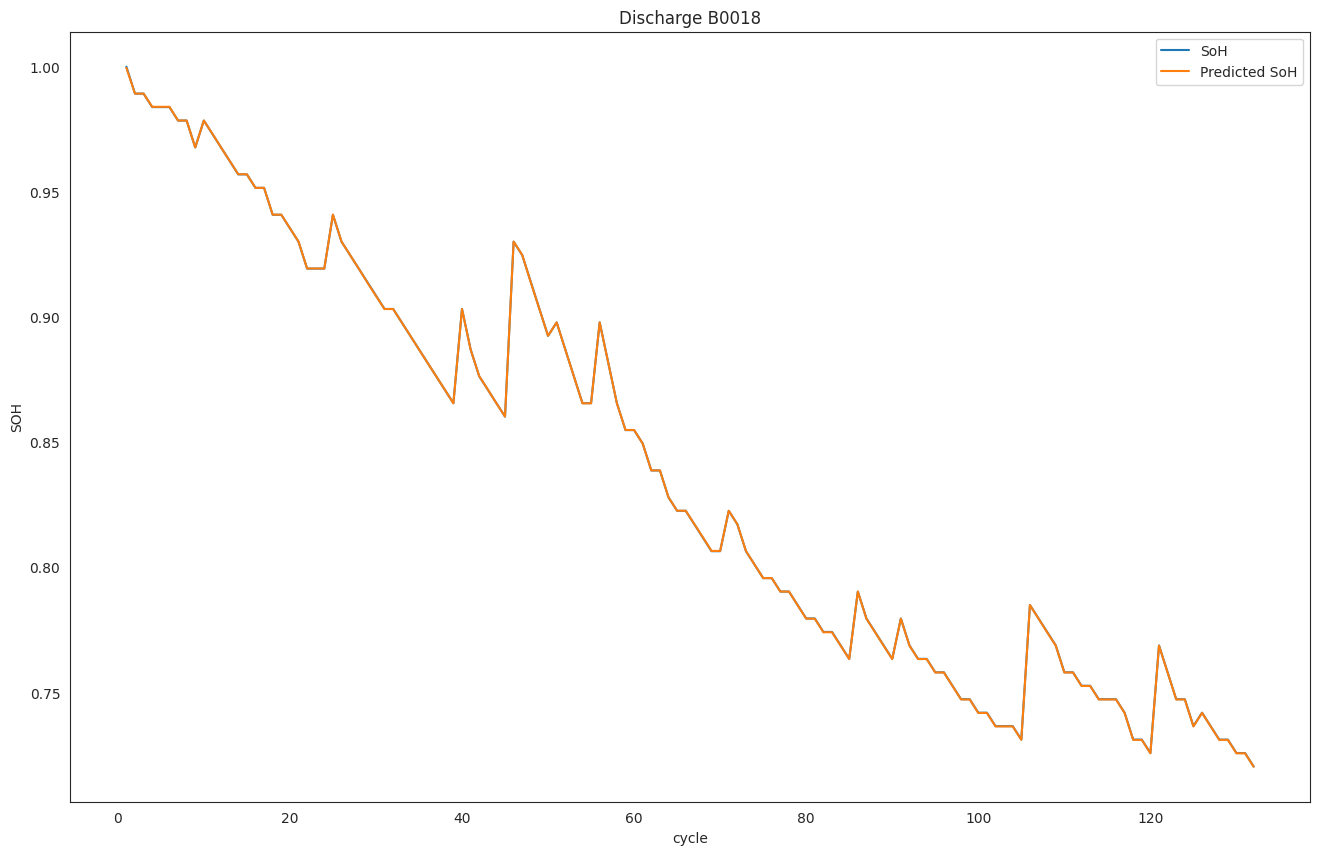

In [ ]:
group = test_dataset.loc[:, ['cycle']].copy()
group['SoH'] = all_targets
group['SOH_pred'] = all_preds
group = group.groupby(['cycle']).mean().reset_index()
plot_df = group.loc[(group['cycle'] >= 1), ['cycle', 'SoH', 'SOH_pred']].copy()
sns.set_style("white")
plt.figure(figsize=(16, 10))
plt.plot(plot_df['cycle'], plot_df['SoH'], label='SoH')
plt.plot(plot_df['cycle'], plot_df['SOH_pred'], label='Predicted SoH')
plt.ylabel('SOH')
plt.xlabel('cycle')
plt.legend()
plt.title('Discharge B0018')
fig = plt.gcf()
plt.show()

.pth file to .ts file

In [ ]:
import torch

# Initialize architecture
model = CNN_GRU_Residual(
    input_dim=5,
    cnn_channels=256,
    gru_hidden=64,
    kernel_size=3,
    dropout=0
)

# Load weights
model.load_state_dict(torch.load("best_model_CNN_GRU_RES.pth", map_location="cpu"))
model.eval()

# Example input
example_input = torch.randn(1, 5)

# Convert
scripted_model = torch.jit.trace(model, example_input)

# Save TorchScript
scripted_model.save("cnn_gru_res_model.ts")

print("Model converted to TorchScript (.ts)")

Model converted to TorchScript (.ts)


Model loaded successfully


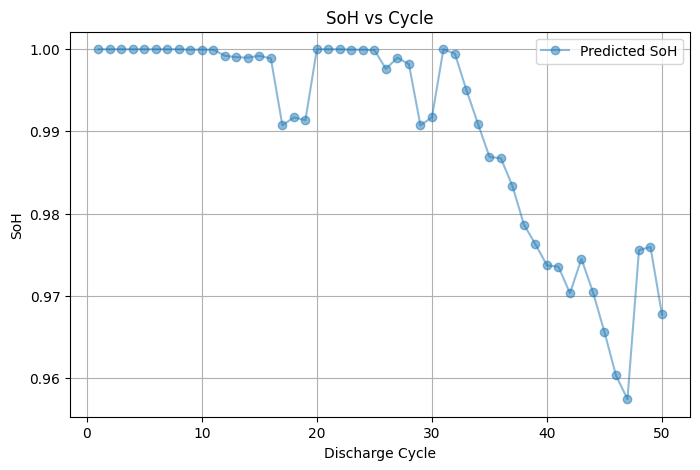

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# -----------------------------
# PATHS
# -----------------------------
MODEL_PATH = "cnn_gru_res_model(5 features).ts"
DATASET_PATH = "B0007_first_50_cycles.xlsx"
SCALER_PATH = "scaler.save"

# -----------------------------
# LOAD MODEL
# -----------------------------
model = torch.jit.load(MODEL_PATH)
model.eval()
print("Model loaded successfully")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel(DATASET_PATH)

# FIX COLUMN ISSUES
df.columns = df.columns.str.strip()

# -----------------------------
# CHECK REQUIRED COLUMN
# -----------------------------
if "cycle_index" not in df.columns:
    raise ValueError("Dataset must contain 'cycle_index' column")

# -----------------------------
# FEATURES (MUST MATCH TRAINING)
# -----------------------------
FEATURES = [
    'capacity',
    'voltage_measured',
    'current_measured',
    'temperature_measured',
    'time'
]

# -----------------------------
# SORT DATA (VERY IMPORTANT)
# -----------------------------
df = df.sort_values(by=["cycle_index", "time"]).reset_index(drop=True)

# -----------------------------
# LOAD SCALER (CORRECT WAY)
# -----------------------------
scaler = joblib.load(SCALER_PATH)

X_scaled = scaler.transform(df[FEATURES])

df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
df_scaled["cycle_index"] = df["cycle_index"]

# -----------------------------
# PREDICT PER CYCLE
# -----------------------------
cycle_predictions = []

for cycle in sorted(df_scaled["cycle_index"].unique()):

    cycle_data = df_scaled[df_scaled["cycle_index"] == cycle]

    X_tensor = torch.tensor(cycle_data[FEATURES].values, dtype=torch.float32)

    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().numpy()

    cycle_soh = float(y_pred[-1])
    cycle_predictions.append((cycle, cycle_soh))

# -----------------------------
# CONVERT TO ARRAY
# -----------------------------
cycles = np.array([c[0] for c in cycle_predictions])
soh_values = np.array([c[1] for c in cycle_predictions])


# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(cycles, soh_values, 'o-', alpha=0.5, label="Predicted SoH")


plt.xlabel("Discharge Cycle")
plt.ylabel("SoH")
plt.title("SoH vs Cycle")

plt.grid()
plt.legend()

plt.savefig("final_soh_plot.png")
plt.show()

KeyError: 'time'

In [ ]:
with open("B0007.mat", "rb") as f:
    print(f.read(100))

b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Wed Oct 01 15:50:27 2008                          '


pipeline :
1) upload .mat file
2) convert to xlsx file
3) get first 50 cycles
4) evaluate it

# conversion to .xlsx file

In [ ]:
import pandas as pd
from scipy.io import loadmat

# -----------------------------
# INPUT
# -----------------------------
MAT_FILE = "B0006.mat"
BATTERY = "B0006"
OUTPUT_FILE = "B0006_discharge_only.xlsx"

# -----------------------------
# LOAD FILE
# -----------------------------
mat = loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)

battery = mat[BATTERY]
cycles = battery.cycle

dataset = []
cycle_index = 0

# -----------------------------
# LOOP THROUGH CYCLES
# -----------------------------
for cycle in cycles:

    cycle_type = cycle.type

    if cycle_type != 'discharge':
        continue

    cycle_index += 1

    data = cycle.data

    capacity = data.Capacity

    time = data.Time
    voltage = data.Voltage_measured
    current = data.Current_measured
    temperature = data.Temperature_measured

    for i in range(len(time)):
        dataset.append([
            cycle_index,
            "discharge",
            time[i],
            voltage[i],
            current[i],
            temperature[i],
            capacity
        ])

# -----------------------------
# CREATE DATAFRAME
# -----------------------------
df = pd.DataFrame(dataset, columns=[
    'cycle_index',
    'cycle_type',
    'Time',
    'Voltage_measured',
    'Current_measured',
    'Temperature_measured',
    'capacity'
])

# -----------------------------
# 🔥 STANDARDIZE COLUMN NAMES
# -----------------------------
def normalize_column(name):
    return name[0].lower() + name[1:] if len(name) > 0 else name

df.columns = [normalize_column(col.strip()) for col in df.columns]

# -----------------------------
# SoH
# -----------------------------
initial_capacity = df[df["cycle_index"] == 1]["capacity"].iloc[0]
df["soh"] = df["capacity"] / initial_capacity

# -----------------------------
# SORT (FIXED)
# -----------------------------
df = df.sort_values(by=["cycle_index", "time"]).reset_index(drop=True)

# -----------------------------
# SAVE
# -----------------------------
df.to_excel(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)
print("Total discharge cycles:", df["cycle_index"].nunique())

Saved: B0007_discharge_only.xlsx
Total discharge cycles: 168


get the 50 cycles

In [ ]:
import pandas as pd

# -----------------------------
# FILES
# -----------------------------
INPUT_FILE = "B0007_discharge_only.xlsx"
OUTPUT_FILE = "B0007_first_50_cycles.xlsx"

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel(INPUT_FILE)

# Fix column issues (important)
df.columns = df.columns.str.strip()

# -----------------------------
# FILTER ONLY DISCHARGE
# -----------------------------
df_discharge = df[df["cycle_type"].str.lower() == "discharge"].copy()

# -----------------------------
# GET FIRST 50 CYCLES
# -----------------------------
unique_cycles = sorted(df_discharge["cycle_index"].unique())

first_50_cycles = unique_cycles[:50]

df_first_50 = df_discharge[df_discharge["cycle_index"].isin(first_50_cycles)].copy()

# -----------------------------
# REINDEX (IMPORTANT)
# -----------------------------
cycle_map = {old: new+1 for new, old in enumerate(first_50_cycles)}
df_first_50["cycle_index"] = df_first_50["cycle_index"].map(cycle_map)

# -----------------------------
# SORT DATA (VERY IMPORTANT)
# -----------------------------
df_first_50 = df_first_50.sort_values(by=["cycle_index", "time"]).reset_index(drop=True)


# -----------------------------
# KEEP ONLY REQUIRED COLUMNS
# -----------------------------
required_columns = [
    'capacity',
    'voltage_measured',
    'current_measured',
    'temperature_measured',
    'time',
    'cycle_index'
]

df_final = df_first_50[required_columns]

# -----------------------------
# SAVE FILE
# -----------------------------
df_final.to_excel(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)
print("Total discharge cycles:", df_final["cycle_index"].nunique())

Saved: B0007_first_50_cycles.xlsx
Total discharge cycles: 50


get the graph

Model loaded successfully


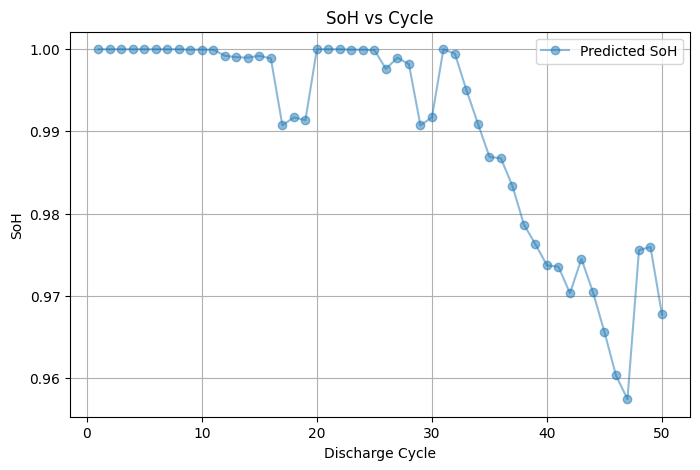

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# -----------------------------
# PATHS
# -----------------------------
MODEL_PATH = "cnn_gru_res_model(5 features).ts"
DATASET_PATH = "B0007_first_50_cycles.xlsx"
SCALER_PATH = "scaler.save"

# -----------------------------
# LOAD MODEL
# -----------------------------
model = torch.jit.load(MODEL_PATH)
model.eval()
print("Model loaded successfully")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_excel(DATASET_PATH)

# FIX COLUMN ISSUES
df.columns = df.columns.str.strip()

# -----------------------------
# CHECK REQUIRED COLUMN
# -----------------------------
if "cycle_index" not in df.columns:
    raise ValueError("Dataset must contain 'cycle_index' column")

# -----------------------------
# FEATURES (MUST MATCH TRAINING)
# -----------------------------
FEATURES = [
    'capacity',
    'voltage_measured',
    'current_measured',
    'temperature_measured',
    'time'
]

# -----------------------------
# SORT DATA (VERY IMPORTANT)
# -----------------------------
df = df.sort_values(by=["cycle_index", "time"]).reset_index(drop=True)

# -----------------------------
# LOAD SCALER (CORRECT WAY)
# -----------------------------
scaler = joblib.load(SCALER_PATH)

X_scaled = scaler.transform(df[FEATURES])

df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
df_scaled["cycle_index"] = df["cycle_index"]

# -----------------------------
# PREDICT PER CYCLE
# -----------------------------
cycle_predictions = []

for cycle in sorted(df_scaled["cycle_index"].unique()):

    cycle_data = df_scaled[df_scaled["cycle_index"] == cycle]

    X_tensor = torch.tensor(cycle_data[FEATURES].values, dtype=torch.float32)

    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().numpy()

    cycle_soh = float(y_pred[-1])
    cycle_predictions.append((cycle, cycle_soh))

# -----------------------------
# CONVERT TO ARRAY
# -----------------------------
cycles = np.array([c[0] for c in cycle_predictions])
soh_values = np.array([c[1] for c in cycle_predictions])


# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(cycles, soh_values, 'o-', alpha=0.5, label="Predicted SoH")


plt.xlabel("Discharge Cycle")
plt.ylabel("SoH")
plt.title("SoH vs Cycle")

plt.grid()
plt.legend()

plt.savefig("final_soh_plot.png")
plt.show()

PRUNING AND QUANTIZATION

In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import numpy as np
import time
import os

# Load Model

MODEL_PATH = "best_model_CNN_GRU_RES(5 features).pth"

model = torch.load(MODEL_PATH, map_location='cpu')
model.eval()

print("Model Loaded Successfully")

# Model Size Function

def get_model_size(model, name="temp.pth"):
    torch.save(model.state_dict(), name)
    size = os.path.getsize(name) / 1e6
    return size

# Baseline Metrics

original_size = get_model_size(model)

dummy_input = torch.randn(1, 5)

start = time.time()
for _ in range(100):
    _ = model(dummy_input)
baseline_time = time.time() - start

print(f"Original Model Size: {original_size:.2f} MB")
print(f"Inference Time (100 runs): {baseline_time:.4f} sec")

# Unstructured Pruning

parameters_to_prune = []

for name, module in model.named_modules():
    if isinstance(module, (nn.Conv1d, nn.Linear)):
        parameters_to_prune.append((module, 'weight'))

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2   # 20% pruning
)

print("Unstructured pruning applied")

# Make Pruning Permanent

for module, _ in parameters_to_prune:
    prune.remove(module, 'weight')

print("Pruning made permanent")

# Structured Pruning

for name, module in model.named_modules():
    if isinstance(module, nn.Conv1d):
        prune.ln_structured(
            module,
            name="weight",
            amount=0.2,
            n=2,
            dim=0
        )
        prune.remove(module, 'weight')

print("Structured pruning applied")

# Quantization

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear, nn.GRU},
    dtype=torch.qint8
)

print("Quantization applied")

# Compare Results

pruned_size = get_model_size(model, "pruned.pth")
quantized_size = get_model_size(quantized_model, "quantized.pth")

# Inference time
start = time.time()
for _ in range(100):
    _ = quantized_model(dummy_input)
quant_time = time.time() - start

print("\n===== COMPARISON =====")
print(f"Original Size   : {original_size:.2f} MB")
print(f"Pruned Size     : {pruned_size:.2f} MB")
print(f"Quantized Size  : {quantized_size:.2f} MB")

print(f"\nOriginal Time   : {baseline_time:.4f} sec")
print(f"Quantized Time  : {quant_time:.4f} sec")

# Save Optimized Model

torch.save(quantized_model.state_dict(), "optimized_model.pth")

print("Optimized model saved")

# Download Model

files.download("optimized_model.pth")

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'